In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os

path = kagglehub.dataset_download("frtgnn/dunnhumby-the-complete-journey")

tx = pd.read_csv(os.path.join(path, "transaction_data.csv"))

tx.columns = tx.columns.str.lower()

tx.head()

,household_key,basket_id,day,product_id,quantity,sales_value,store_id,retail_disc,trans_time,week_no,coupon_disc,coupon_match_disc
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [2]:
# find the actual day in data
referance_day = tx.day.max()
referance_day

np.int64(711)

In [3]:
rfm = tx.groupby('household_key').agg(
    last_day = ("day" , "max"),
    frequency = ("basket_id", "nunique"),
    monetary = ("sales_value" , "sum")
    )

In [4]:
print(rfm.shape, rfm.monetary.sum(), tx.sales_value.sum())

(2500, 3) 8057463.08 8057463.08


In [5]:
referance_day - rfm.last_day

household_key
1        5
2       43
3        8
4       84
5        8
        ..
2496    28
2497    11
2498     1
2499     2
2500     3
Name: last_day, Length: 2500, dtype: int64

In [6]:
(referance_day - rfm.last_day).value_counts()

last_day
0      367
1      262
2      194
3      157
6      117
      ... 
111      1
270      1
108      1
230      1
168      1
Name: count, Length: 200, dtype: int64

In [7]:
rfm["recency"] = referance_day - rfm.last_day

In [8]:
rfm.recency.describe()

count    2500.000000
mean       25.574000
std        62.790655
min         0.000000
25%         1.000000
50%         6.000000
75%        20.000000
max       657.000000
Name: recency, dtype: float64

In [9]:
rfm.frequency.describe()

count    2500.000000
mean      110.593600
std       115.669368
min         1.000000
25%        39.000000
50%        79.000000
75%       142.250000
max      1300.000000
Name: frequency, dtype: float64

In [10]:
rfm.monetary.describe()

count     2500.000000
mean      3222.985232
std       3349.026076
min          8.170000
25%        970.740000
50%       2157.750000
75%       4413.320000
max      38319.790000
Name: monetary, dtype: float64

Recency is scored with fixed day bins instead of quintiles, because 367 households have recency 0 and quintiles would split identical values into different scores.

The median household makes 79 visits in 711 days, about one visit every 9 days. The bins therefore roughly count how many normal visits a household has missed.

In [11]:
r_score_conditions = [
    rfm["recency"] <= 7,
    rfm["recency"] <= 14,
    rfm["recency"] <= 30,
    rfm["recency"] <= 60
]
values = [5, 4, 3, 2]

rfm["r_score"] = np.select(r_score_conditions, values, default = 1)

In [12]:
rfm["r_score"].value_counts()

r_score
5    1407
3     338
4     301
1     255
2     199
Name: count, dtype: int64

In [13]:
rfm["f_score"] = pd.qcut(rfm["frequency"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

In [14]:
rfm["m_score"] = pd.qcut(rfm["monetary"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

In [15]:
rfm["f_score"].value_counts()

f_score
2    505
1    502
3    499
5    498
4    496
Name: count, dtype: int64

In [16]:
rfm["m_score"].value_counts()

m_score
4    500
3    500
2    500
5    500
1    500
Name: count, dtype: int64

In [17]:
rfm[["frequency", "monetary"]].corr(method="spearman")
# value_score method usable because there is a strong correlation between frequency and monetary

,frequency,monetary
frequency,1.000000,0.845523
monetary,0.845523,1.000000


In [18]:
pd.crosstab(rfm["f_score"], rfm["m_score"])
# it means most households sit on the diagonal. frequent shoppers are also high spenders.

m_score,1,2,3,4,5
f_score,,,,,
1,362,113,23,4,0
2,116,233,118,35,3
3,20,114,190,136,39
4,2,36,125,201,132
5,0,4,44,124,326


In [19]:
rfm["value_score"] = (rfm.f_score + rfm.m_score) / 2

| Segment | Rule | Meaning |
| High-Value Active | R ≥ 4 and value ≥ 4 | Recent and very valuable |
| Mid-Value Active | R ≥ 4 and value ≥ 3 | Recent and valuable |
| High-Value Lapsing | R ≤ 3 and value ≥ 3 | Valuable, but drifting away |
| Low-Value Lapsed | R ≤ 2 and value < 3 | Low value, no longer shopping |
| Low-Value Active | everything else | Still shopping, but spends little |

High-value households are marked as lapsing already at 15+ days of absence (R ≤ 3), because they normally shop every few days. With R ≤ 2 only, this segment had just 82 households, too small to analyse in Phase 4.

In [20]:
segment_conditions = [
    (rfm.r_score >= 4) & (rfm.value_score >= 4),
    (rfm.r_score >= 4) & (rfm.value_score >= 3),
    (rfm.r_score <= 3) & (rfm.value_score >= 3),
    (rfm.r_score <= 2) & (rfm.value_score < 3),
]

segments = ["High-Value Active","Mid-Value Active","High-Value Lapsing","Low-Value Lapsed"]
rfm["segments"] = np.select(segment_conditions, segments, default = "Low-Value Active")

In [21]:
rfm["segments"].value_counts()

segments
High-Value Active     782
Low-Value Active      733
Mid-Value Active      418
Low-Value Lapsed      372
High-Value Lapsing    195
Name: count, dtype: int64

In [22]:
segment_profile   = rfm.groupby('segments').agg(
    households    = ('monetary', 'count'),
    avg_recency   = ('recency', 'mean'),
    avg_monetary  = ('monetary','mean'),
    avg_frequency = ('frequency', 'mean'),
    total_revenue = ('monetary','sum')
)

In [23]:
segment_profile["total_revenue"].sum()

np.float64(8057463.08)

In [24]:
tx["sales_value"].sum()
# check potential mistakes

np.float64(8057463.08)

In [25]:
rfm

,last_day,frequency,monetary,recency,r_score,f_score,m_score,value_score,segments
household_key,,,,,,,,,
1,706,86,4330.16,5,5,3,4,3.5,Mid-Value Active
2,668,45,1954.34,43,2,2,3,2.5,Low-Value Lapsed
3,703,47,2653.21,8,4,2,3,2.5,Low-Value Active
4,627,30,1200.11,84,1,1,2,1.5,Low-Value Lapsed
5,703,40,779.06,8,4,2,2,2.0,Low-Value Active
...,...,...,...,...,...,...,...,...,...
2496,683,63,4339.66,28,3,3,4,3.5,High-Value Lapsing
2497,700,221,7111.98,11,4,5,5,5.0,High-Value Active
2498,710,172,2601.60,1,5,5,3,4.0,High-Value Active


In [26]:
segment_profile["households_pct"] = (segment_profile.households / segment_profile.households.sum()) * 100

In [27]:
segment_profile["revenue_pct"] = (segment_profile.total_revenue / segment_profile.total_revenue.sum()) *100

In [28]:
segment_profile = segment_profile.sort_values("revenue_pct", ascending=False)

In [29]:
segment_profile

,households,avg_recency,avg_monetary,avg_frequency,total_revenue,households_pct,revenue_pct
segments,,,,,,,
High-Value Active,782,2.855499,6665.382532,220.631714,5212329.14,31.28,64.689457
Mid-Value Active,418,4.203349,2605.029665,95.327751,1088902.40,16.72,13.514209
Low-Value Active,733,9.899045,1085.158990,42.567531,795421.54,29.32,9.871861
High-Value Lapsing,195,44.543590,3655.451231,119.774359,712812.99,7.80,8.846618
Low-Value Lapsed,372,118.287634,666.658629,25.658602,247997.01,14.88,3.077855


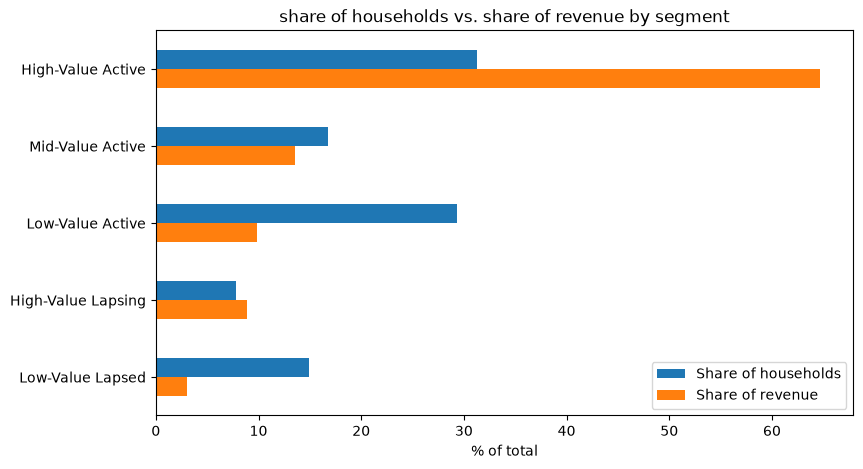

In [30]:
ax = segment_profile[["households_pct", "revenue_pct"]].rename(columns={"households_pct": "Share of households", "revenue_pct": "Share of revenue"}).plot(kind="barh", figsize=(9, 5))

ax.set_title("share of households vs. share of revenue by segment")
ax.set_xlabel("% of total")
ax.set_ylabel("")
ax.invert_yaxis()

In [31]:
os.makedirs("images", exist_ok=True)
ax.figure.savefig("images/segment_share.png", bbox_inches="tight", dpi=150)

## Key findings

- **Revenue is highly concentrated.** High-Value Active households make up 31% of the customer base but generate 65% of total revenue.
- **High-Value Lapsing is the priority segment for retention.** These 195 households (8% of the base) used to shop roughly every 6 days, but have been absent for 44 days on average. They generated $713K (9% of revenue) over the two years.
- **Low-Value Lapsed households are a weak retention target.** They are 15% of the base but only 3% of revenue.

Whether a coupon actually brings High-Value Lapsing households back, rather than just discounting purchases they would make anyway, is tested in Phase 4.